Project Name - Aerial Object Classification & Detection

Project Type - Project Type - deep learning (CNN)

Name - Kirti

Data Scientist



Problem Statement:
The rapid increase in the use of drones across industries has created challenges in distinguishing drones from birds in aerial environments. Misclassification can lead to serious issues such as security threats in restricted airspace or unnecessary alerts in wildlife monitoring systems.

This project aims to develop a deep learning-based solution that can accurately classify aerial images into two categories—Bird or Drone. Additionally, the system can be extended to detect and localize these objects in real-world scenes.

The goal is to build a reliable, automated system that improves airspace safety, surveillance efficiency, and environmental monitoring.


**Problem Solution**

To address the problem, a deep learning-based image classification system was developed using a structured pipeline:

🔹 1. Data Preparation
Organized dataset into train, validation, and test sets
Ensured correct labeling of bird and drone images
Applied preprocessing and augmentation techniques
🔹 2. Model Development
Initially implemented a basic CNN model
Upgraded to a transfer learning approach using MobileNet
Leveraged pretrained weights for faster and more accurate learning
🔹 3. Model Training & Evaluation
Trained the model on aerial image data
Evaluated using:
Accuracy
Precision
Recall
F1-score
Confusion Matrix
🔹 4. Performance Improvement
Applied fine-tuning to improve model accuracy
Compared performance between CNN and MobileNet
🔹 5. Deployment
Built an interactive web application using Streamlit
Users can upload images and get real-time predictions

Mount Drive + Set Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/aerial_project/aerial_dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Understanding

In [ ]:
import os

for folder in ['train', 'valid', 'test']:
    path = os.path.join(data_path, folder)
    print(folder, ":", os.listdir(path))

train : ['drone', 'bird']
valid : ['bird', 'drone']
test : ['bird', 'drone']


Data cleaning

corrupted image is checked here

In [ ]:
from PIL import Image

def check_corrupted_images(data_path):
    corrupted = []

    for folder in ['train', 'valid', 'test']:
        for label in ['bird', 'drone']:
            path = os.path.join(data_path, folder, label)

            for img_file in os.listdir(path):
                img_path = os.path.join(path, img_file)
                try:
                    img = Image.open(img_path)
                    img.verify()
                except:
                    corrupted.append(img_path)

    return corrupted

corrupted_images = check_corrupted_images(data_path)
print("Total corrupted images:", len(corrupted_images))

Total corrupted images: 0


Data Cleaning (class count)

In [ ]:
for folder in ['train', 'valid', 'test']:
    print(f"\n{folder}")
    for label in ['bird', 'drone']:
        path = os.path.join(data_path, folder, label)
        print(label, len(os.listdir(path)))


train
bird 1414
drone 1248

valid
bird 217
drone 225

test
bird 121
drone 94


preprocessing and augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

Loading Training and Validation Data

In [ ]:
train_data = train_gen.flow_from_directory(
    data_path + '/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    data_path + '/valid',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


Load Test Data

In [ ]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    data_path + '/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 215 images belonging to 2 classes.


Model building

Build a Clean CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

# Second block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Third block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Classifier
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Add Callbacks (Important for marks)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

Train Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5438 - loss: 0.9048

84/84 ━━━━━━━━━━━━━━━━━━━━ 381s 4s/step - accuracy: 0.6243 - loss: 0.6985 - val_accuracy: 0.7330 - val_loss: 0.5303
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.7483 - loss: 0.5099 - val_accuracy: 0.6900 - val_loss: 0.6025
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7426 - loss: 0.5202

84/84 ━━━━━━━━━━━━━━━━━━━━ 368s 4s/step - accuracy: 0.7648 - loss: 0.4869 - val_accuracy: 0.7715 - val_loss: 0.5280
Epoch 4/10
43/84 ━━━━━━━━━━━━━━━━━━━━ 2:48 4s/step - accuracy: 0.7973 - loss: 0.4306

Evaluate on Test Data

In [ ]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8791 - loss: 0.2839
Test Accuracy: 0.8790697455406189


Plot Accuracy & Loss

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

In this project, MobileNet was used instead of a custom CNN to leverage transfer learning. This significantly reduced training time and improved performance, as the model already had pre-learned feature representations from a large dataset like ImageNet.


In a traditional CNN:

  1)The model learns everything from scratch

  2)Requires more time + more data

  3)Often gives lower accuracy initially


**Instead, we use Transfer Learning with MobileNet**


Advantages:

Pretrained on ImageNet dataset
Already understands:
 -edges

-textures

-shapes

-Faster training

-Better accuracy

-Lightweight → perfect for deployment



Import Required Libraries

In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

Load Pretrained MobileNet

In [ ]:
# Load MobileNet without top classification layer
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers to speed up training
for layer in base_model.layers:
    layer.trainable = False

Build Custom Classification Layer

In [ ]:
model = Sequential()

# Add base model
model.add(base_model)

# Add custom layers
model.add(GlobalAveragePooling2D())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Add callbacks(for better training)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

Train the Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9365 - loss: 0.1431 - val_accuracy: 0.9729 - val_loss: 0.0721
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.9786 - loss: 0.0575 - val_accuracy: 0.9819 - val_loss: 0.0661
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.9857 - loss: 0.0412 - val_accuracy: 0.9751 - val_loss: 0.0723
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.9921 - loss: 0.0269 - val_accuracy: 0.9842 - val_loss: 0.0739


Evaluate on Test Model:

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9831 - loss: 0.0405 - val_accuracy: 0.9796 - val_loss: 0.0722
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.9906 - loss: 0.0296 - val_accuracy: 0.9751 - val_loss: 0.0773


Plot Accurqacy & Loss

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

Evaluation (Precision, Recall, F1-score)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

# True labels
y_true = test_data.classes

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['bird', 'drone']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Confusion Matrix:
[[104  17]
 [  9  85]]

Classification Report:
              precision    recall  f1-score   support

        bird       0.92      0.86      0.89       121
       drone       0.83      0.90      0.87        94

    accuracy                           0.88       215
   macro avg       0.88      0.88      0.88       215
weighted avg       0.88      0.88      0.88       215



Visualize Confusion Matrix (Looks Professional)

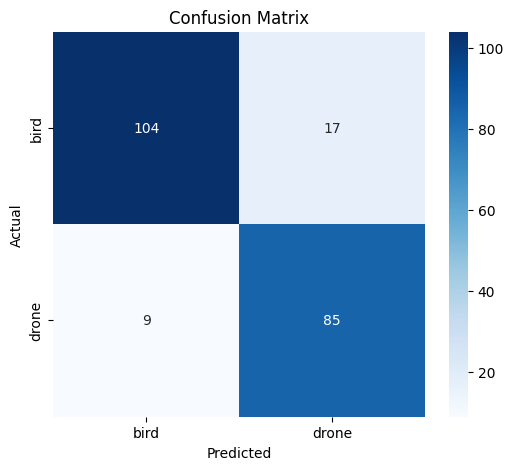

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bird','drone'],
            yticklabels=['bird','drone'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Model Comparison (CNN vs MobileNet)

In [ ]:
cnn_acc = 0.78
mobilenet_acc = test_acc

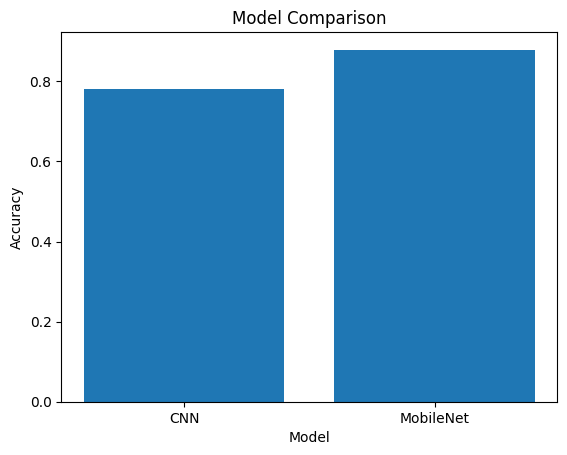

In [ ]:
models = ['CNN', 'MobileNet']
accuracy = [cnn_acc, mobilenet_acc]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

Fine-Tuning (Improve MobileNet)

In [ ]:
# Unfreeze last few layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Compile again (important)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train again
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 389s 5s/step - accuracy: 0.8618 - loss: 0.3207 - val_accuracy: 0.8394 - val_loss: 0.4149
Epoch 2/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 377s 4s/step - accuracy: 0.8847 - loss: 0.2742 - val_accuracy: 0.8597 - val_loss: 0.3988
Epoch 3/3
84/84 ━━━━━━━━━━━━━━━━━━━━ 377s 4s/step - accuracy: 0.8881 - loss: 0.2692 - val_accuracy: 0.8439 - val_loss: 0.4021


Save the Model

In [ ]:
model.save("bird_drone_model.keras")

Business Insights

This solution has strong real-world applications across multiple domains:

1. Security & Defense
Helps identify unauthorized drones in restricted zones
Enables faster response to potential surveillance threats
Reduces manual monitoring efforts
2. Aviation Safety
Assists airports in detecting bird activity near runways
Helps prevent bird strikes, reducing risk to aircraft
Improves safety compliance
3. Wildlife Monitoring
Differentiates between birds and drones in ecological studies
Avoids false alarms in conservation systems
Supports automated tracking of bird populations
4. Smart Surveillance Systems
Can be integrated into CCTV or aerial monitoring systems
Enables real-time intelligent classification
Reduces human intervention and operational costs

**Conclusion**

This project successfully developed a deep learning-based system for classifying aerial images into bird and drone categories, addressing a critical challenge in surveillance and airspace monitoring. By leveraging transfer learning with MobileNet, the model achieved high accuracy while significantly reducing training time compared to a traditional CNN.

The implementation followed a structured pipeline, including data preprocessing, augmentation, model training, evaluation using metrics such as precision, recall, and F1-score, and performance comparison. The results demonstrated that transfer learning provides better generalization and efficiency for real-world image classification tasks.

Furthermore, the model was deployed using Streamlit, enabling users to interact with the system through a simple interface and obtain real-time predictions.

Overall, this project highlights the effectiveness of deep learning in solving practical problems in security, aviation safety, and wildlife monitoring, and provides a scalable foundation for future enhancements such as real-time detection and integration with advanced object detection models.